In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import chi2_contingency

#from sklearn.pipeline import Pipeline
#from sklearn.compose import ColumnTransformer
#from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
#from sklearn.linear_model import LinearRegression, Lasso, Ridge
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
df = pd.read_csv("sales_data.csv")

In [ ]:
df.shape

(128949, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount_original     121155 non-null  float64
 15  ship-city           128916 non-nul

In [ ]:
df.describe()

,Qty,Amount_original,ship-postal-code
count,128949.00,121155.00,128916.00
mean,0.90,648.55,463978.30
std,0.31,281.22,191473.32
min,0.00,0.00,110001.00
25%,1.00,449.00,382421.00
50%,1.00,605.00,500033.00
75%,1.00,788.00,600024.00
max,15.00,5584.00,989898.00


In [ ]:
df.shape

(128949, 23)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0
Size,0


## Dropping duplicates based on orderid, style,skus

In [ ]:
df.duplicated(subset=['Order ID', 'Style', 'SKU']).sum()

np.int64(7)

In [ ]:
df.shape

(128949, 23)

In [ ]:
df['Amount'] = df['Amount_original']

In [ ]:
df = df.drop_duplicates(
    subset=['Order ID', 'Style', 'SKU'],
    keep='first'
)

## Cleaning & Formatting date column

In [ ]:
df['date_clean'] = pd.to_datetime(
    df['Date'],
    errors='coerce'
)

In [ ]:
df['year'] = df['date_clean'].dt.year
df['month'] = df['date_clean'].dt.month
df['quarter'] = df['date_clean'].dt.quarter
df["Day_Name"] = pd.to_datetime(df["date_clean"]).dt.day_name()
df["Day_Type"] = np.where(
    df["date_clean"].dt.weekday >= 5,  # 5=Saturday, 6=Sunday
    "Weekend",
    "Weekday"
)

In [ ]:
df["Is_Cancelled"] = df["Status"].isin(["Cancelled", "Shipped - Returned to Seller",
                                        "Shipped - Rejected by Buyer","Shipped - Returning to Seller"]).astype(int)

df["Order_Success"] = df["Status"].isin(
    ["Shipped - Delivered to Buyer", "Shipped"]
).astype(int)

df["In_Process"] = df["Status"].isin(
    ["Shipped - Lost in Transit", "Shipped - Out for Delivery",
     "Shipped - Picked Up","Pending","Pending - Waiting for Pick Up","Shipped - Damaged","Shipping"]
).astype(int)

In [ ]:
df[df["Is_Cancelled"]==1].shape

(20447, 33)

In [ ]:
df['Amount'] = df['Amount'].fillna(
    df.groupby(['Style','Is_Cancelled','In_Process','Order_Success'])['Amount']
      .transform('median')
)

df['Amount'] = df['Amount'].fillna(df['Amount'].median())

In [ ]:
df['Amount'].isnull().sum()

np.int64(0)

In [ ]:
df[df['Amount'].isna()]

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Amount,date_clean,year,month,quarter,Day_Name,Day_Type,Is_Cancelled,Order_Success,In_Process


## Univariate Analysis

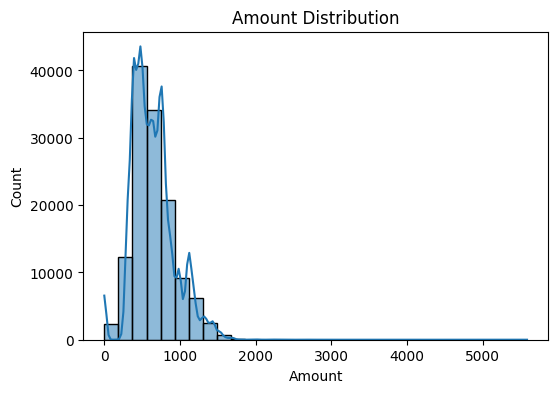

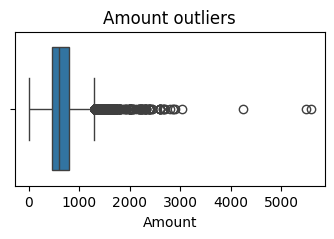

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Amount"], bins=30, kde=True)
plt.title("Amount Distribution")
plt.show()

plt.figure(figsize=(4,2))
sns.boxplot(x=df["Amount"])
plt.title("Amount outliers")
plt.show()

As per the histogram, we can see 250-1000 is the range which most of the people Ordering,
Also as per the box plot there are also outliers where people have Ordered worth more than 3k.

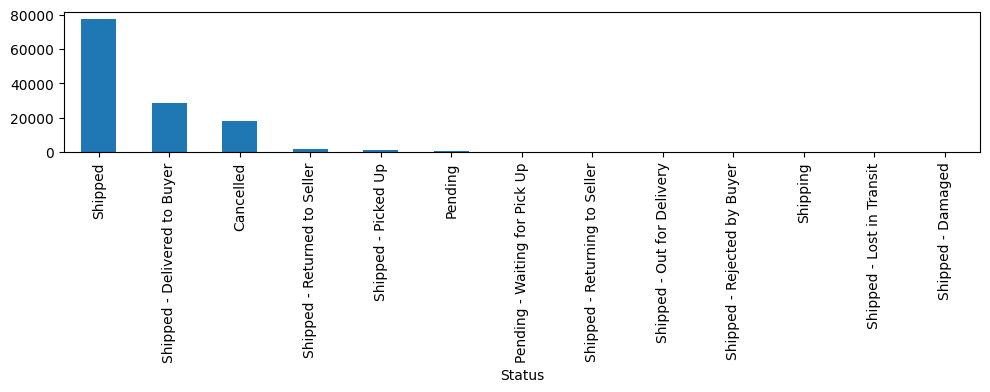

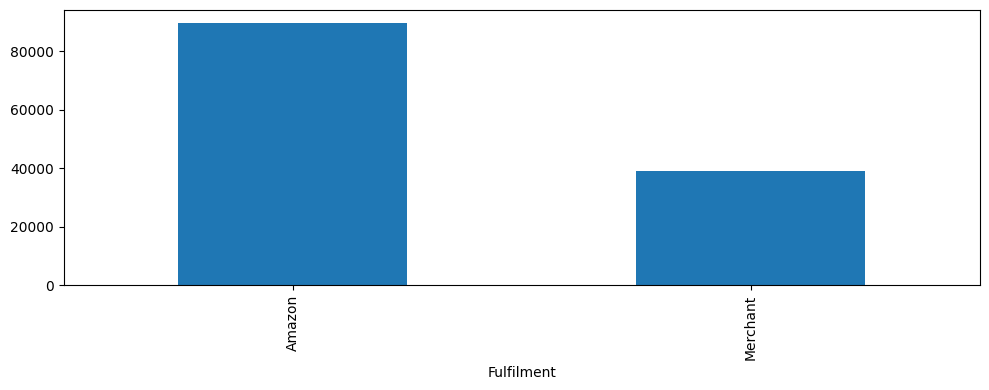

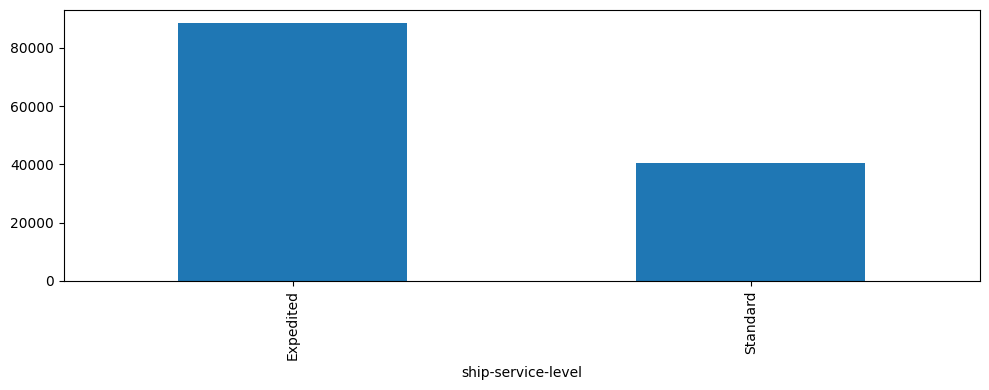

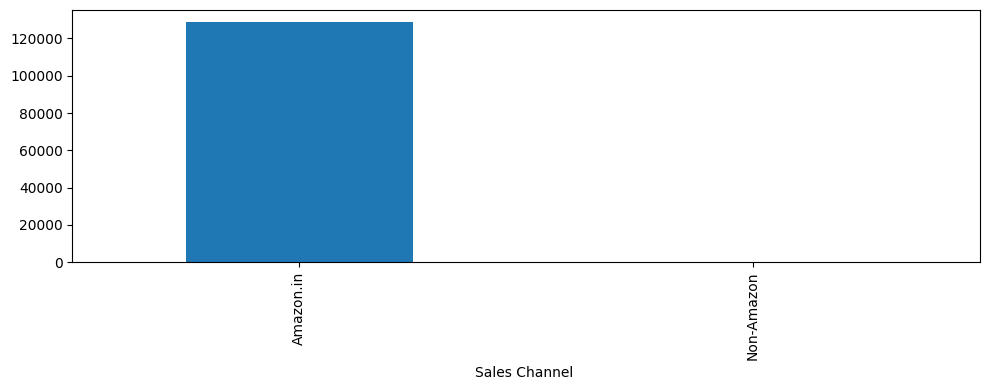

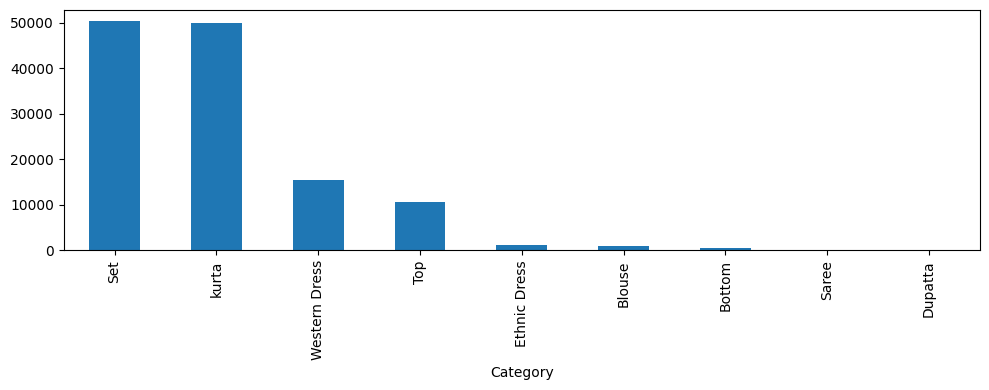

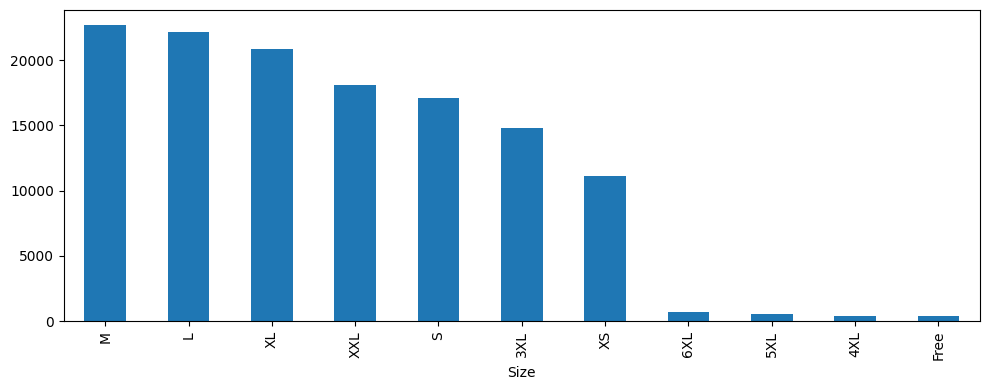

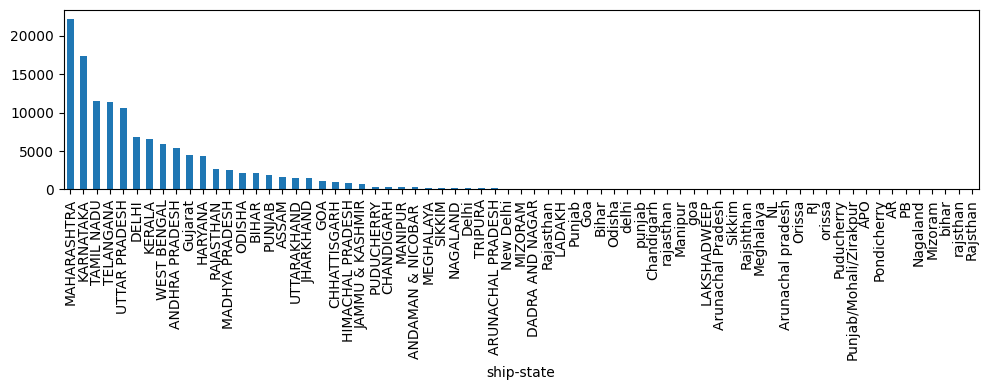

In [ ]:
cols=['Status','Fulfilment','ship-service-level','Sales Channel ','Category','Size','ship-state']
#clean_cols= [i.strip() for i in cols]

for i in cols:
    plt.figure(figsize=(10, 4))
    df[i].value_counts().plot(
        kind="bar")

    plt.xlabel(i)
    plt.tight_layout()
    plt.show()



Most of the people have accepted the delivery than cancelling it.
Majorly fullfilled by amazon, followed by expedited facilty.Set & kurta seems to be the most ordered items.
Size M is the most ordered size indicating there are more of M size people.Highest no. of orders coming from maharashtra, karnataka, tamil nadu.

## Bivariate Analysis

Financial performance analysis

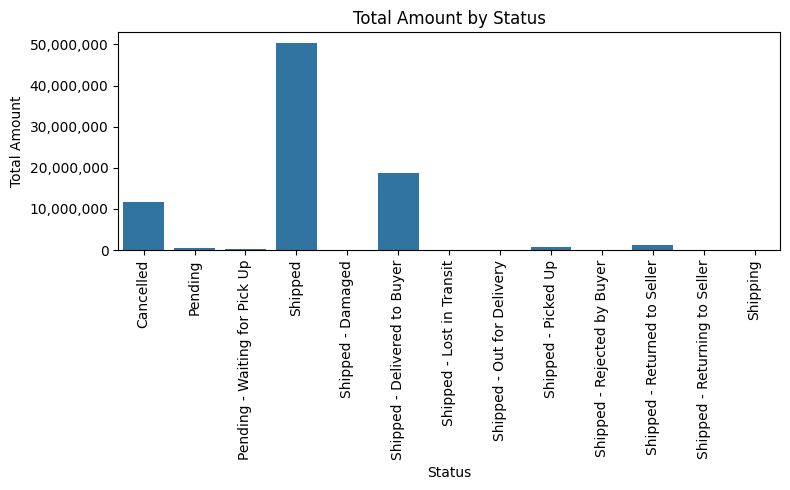

In [ ]:
## relationship between amount and status.
import matplotlib.ticker as mtick

sum_df = (
    df.groupby('Status', as_index=False)['Amount']
    .sum()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=sum_df, x='Status', y='Amount')

plt.title('Total Amount by Status')
plt.ylabel('Total Amount')
plt.xlabel('Status')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount_original', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22', 'Amount', 'date_clean', 'year',
       'month', 'quarter', 'Day_Name', 'Day_Type', 'Is_Cancelled',
       'Order_Success', 'In_Process'],
      dtype='object')

**Monthly  Realized Revenue , cancellation & In process **

In [ ]:
monthly_revenue = (
    df.groupby(['year', 'month'])
    .agg(
        Revenue_Success=("Amount", lambda x: x[df.loc[x.index, "Order_Success"] == 1].sum()),
        Revenue_Cancelled=("Amount", lambda x: x[df.loc[x.index, "Is_Cancelled"] == 1].sum()),
        Revenue_InTransit=("Amount", lambda x: x[df.loc[x.index, "In_Process"] == 1].sum()),

        # 🔢 Counts
        Total_Records=("Amount", "count"),
        Success_Count=("Order_Success", "sum"),
        Cancelled_Count=("Is_Cancelled", "sum"),
        InTransit_Count=("In_Process", "sum"),

        # ⭐ Unique counts (example columns)
        #Unique_Customers=("customer_id", "nunique"),
        Unique_Orders=("Order ID", "nunique")
    )
    .reset_index()
)



In [ ]:
monthly_revenue["Year_Month"] = pd.to_datetime(
    monthly_revenue["year"].astype(str) + "-" + monthly_revenue["month"].astype(str)
)

In [ ]:
monthly_revenue

,year,month,Revenue_Success,Revenue_Cancelled,Revenue_InTransit,Total_Records,Success_Count,Cancelled_Count,InTransit_Count,Unique_Orders,Year_Month
0,2022,3,94674.00,14940.78,0.00,171,152,19,0,158,2022-03-01
1,2022,4,25717738.12,5013773.22,4312.00,49056,41010,8038,8,45849,2022-04-01
2,2022,5,23493859.50,4361913.46,11739.00,42031,35413,6601,17,39216,2022-05-01
3,2022,6,19781471.00,3792312.50,1305998.00,37684,29959,5789,1936,35129,2022-06-01


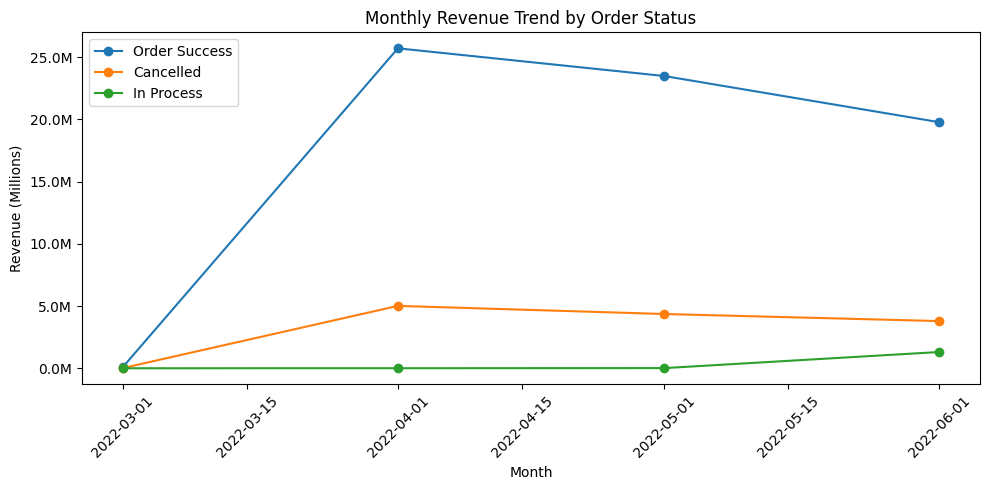

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,5))

# Success
plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["Revenue_Success"] / 1_000_000,
    marker="o",
    label="Order Success"
)

# Cancelled
plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["Revenue_Cancelled"] / 1_000_000,
    marker="o",
    label="Cancelled"
)

# In Transit
plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["Revenue_InTransit"] / 1_000_000,
    marker="o",
    label="In Process"
)

plt.title("Monthly Revenue Trend by Order Status")
plt.xlabel("Month")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=45)

# Format Y axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}M"))

plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# weekly_revenue = (
#     df.groupby(['month','Day_Name'])['Amount']
#     .sum()
#     .reset_index()
#     .sort_values(['month','Day_Name'])
# )

# weekly_revenue


Daywise_revenue = (
    df.groupby(['month','Day_Name'])
    .agg(
        Revenue_Success=("Amount", lambda x: x[df.loc[x.index, "Order_Success"] == 1].sum()),
        Revenue_Cancelled=("Amount", lambda x: x[df.loc[x.index, "Is_Cancelled"] == 1].sum()),
        Revenue_InTransit=("Amount", lambda x: x[df.loc[x.index, "In_Process"] == 1].sum())
    )
    .reset_index()
)

print(Daywise_revenue)

    month   Day_Name  Revenue_Success  Revenue_Cancelled  Revenue_InTransit
0       3   Thursday         94674.00           14940.78               0.00
1       4     Friday       4218709.00          860483.28               0.00
2       4     Monday       3272206.50          676482.79             399.00
3       4   Saturday       4393174.62          891779.41               0.00
4       4     Sunday       3674213.00          679182.15               0.00
5       4   Thursday       3446526.00          629156.90            1115.00
6       4    Tuesday       3316295.00          639860.54             825.00
7       4  Wednesday       3396614.00          636828.18            1973.00
8       5     Friday       2836715.00          504658.37            1056.00
9       5     Monday       3858855.00          725975.06            2521.00
10      5   Saturday       2896036.00          518306.34               0.00
11      5     Sunday       4018915.00          732277.85            3535.00
12      5   

**Daywise revenue**

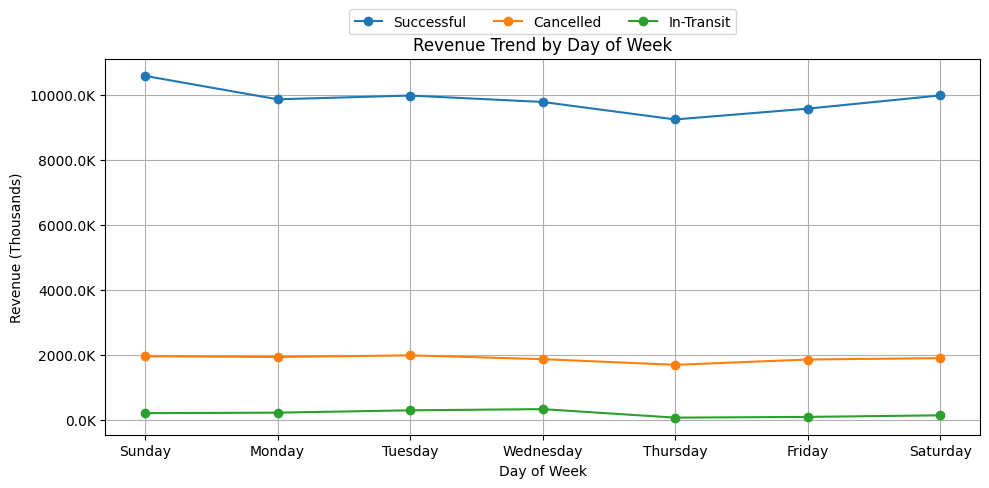

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Step 1: Create weekday revenue
Daywise_revenue = (
    df.assign(
        Revenue_Success = df['Amount'] * df['Order_Success'],
        Revenue_Cancelled = df['Amount'] * df['Is_Cancelled'],
        Revenue_InTransit = df['Amount'] * df['In_Process']
    )
    .groupby('Day_Name')[['Revenue_Success','Revenue_Cancelled','Revenue_InTransit']]
    .sum()
    .reset_index()
)

# Step 2: Sort weekdays
weekday_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

Daywise_revenue['Day_Name'] = pd.Categorical(
    Daywise_revenue['Day_Name'],
    categories=weekday_order,
    ordered=True
)

Daywise_revenue = Daywise_revenue.sort_values('Day_Name')

# Step 3: Plot
plt.figure(figsize=(10,5))

# Plot all 3 revenue types as trend lines
plt.plot(Daywise_revenue['Day_Name'], Daywise_revenue['Revenue_Success'], marker='o', label='Successful')
plt.plot(Daywise_revenue['Day_Name'], Daywise_revenue['Revenue_Cancelled'], marker='o', label='Cancelled')
plt.plot(Daywise_revenue['Day_Name'], Daywise_revenue['Revenue_InTransit'], marker='o', label='In-Transit')

# Format Y-axis (Thousands)
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}K')
)

# Titles and labels
plt.title("Revenue Trend by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue (Thousands)")
plt.xticks(rotation=0)

# Legend on top
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
Daywise_revenue

,Day_Name,Revenue_Success,Revenue_Cancelled,Revenue_InTransit
3,Sunday,10595887.00,1956443.62,202335.00
1,Monday,9874789.50,1931306.11,217595.00
5,Tuesday,9989926.50,1983505.91,289414.00
6,Wednesday,9792728.00,1867134.67,326346.00
4,Thursday,9253547.00,1691713.94,64120.00
0,Friday,9586664.00,1854705.93,86892.00
2,Saturday,9994200.62,1898129.78,135347.00


In [ ]:
df['week'] = df['date_clean'].dt.isocalendar().week
# weekly_revenue = (
#     df.groupby(['month','week'])['Amount']
#     .sum()
#     .reset_index()
#     .sort_values(['month','week'])
# )

# weekly_revenue

weekly_revenue = (
    df.groupby(['month','week'])
    .agg(
        Revenue_Success=("Amount", lambda x: x[df.loc[x.index, "Order_Success"] == 1].sum()),
        Revenue_Cancelled=("Amount", lambda x: x[df.loc[x.index, "Is_Cancelled"] == 1].sum()),
        Revenue_InTransit=("Amount", lambda x: x[df.loc[x.index, "In_Process"] == 1].sum())
    )
    .reset_index()
)

weekly_revenue["month_week"] = (
    "M" + weekly_revenue["month"].astype(str) +
    "-W" + weekly_revenue["week"].astype(str)
)

weekly_revenue


,month,week,Revenue_Success,Revenue_Cancelled,Revenue_InTransit,month_week
0,3,13,94674.00,14940.78,0.00,M3-W13
1,4,13,2489650.00,508548.32,0.00,M4-W13
2,4,14,6005467.50,1093669.21,2372.00,M4-W14
3,4,15,6102510.05,1265751.20,825.00,M4-W15
4,4,16,6332510.00,1182432.79,1115.00,M4-W16
5,4,17,4787600.57,964510.70,0.00,M4-W17
6,5,17,995097.00,146259.65,635.00,M5-W17
7,5,18,6492343.00,1218873.06,1685.00,M5-W18
8,5,19,4689219.00,992500.80,680.00,M5-W19
9,5,20,4662465.00,910420.47,4763.00,M5-W20


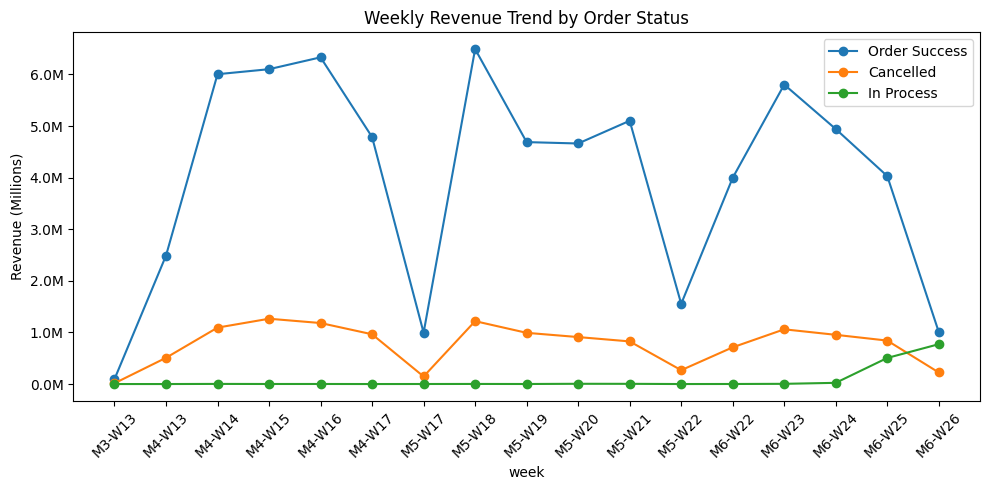

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,5))

# Success
plt.plot(
    weekly_revenue["month_week"],
    weekly_revenue["Revenue_Success"] / 1_000_000,
    marker="o",
    label="Order Success"
)

# Cancelled
plt.plot(
    weekly_revenue["month_week"],
    weekly_revenue["Revenue_Cancelled"] / 1_000_000,
    marker="o",
    label="Cancelled"
)

# In Transit
plt.plot(
    weekly_revenue["month_week"],
    weekly_revenue["Revenue_InTransit"] / 1_000_000,
    marker="o",
    label="In Process"
)

plt.title("Weekly Revenue Trend by Order Status")
plt.xlabel("week")
plt.ylabel("Revenue (Millions)")
plt.xticks(rotation=45)

# Format Y axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}M"))

plt.legend()

plt.tight_layout()
plt.show()


**Revenue by Weekday/Weekend**

In [ ]:

DayType_revenue = (
    df.groupby(['month','Day_Type'])
    .agg(
        Revenue_Success=("Amount", lambda x: x[df.loc[x.index, "Order_Success"] == 1].sum()),
        Revenue_Cancelled=("Amount", lambda x: x[df.loc[x.index, "Is_Cancelled"] == 1].sum()),
        Revenue_InTransit=("Amount", lambda x: x[df.loc[x.index, "In_Process"] == 1].sum())
    )
    .reset_index()
)


print(DayType_revenue)



   month Day_Type  Revenue_Success  Revenue_Cancelled  Revenue_InTransit
0      3  Weekday         94674.00           14940.78               0.00
1      4  Weekday      17650350.50         3442811.67            4312.00
2      4  Weekend       8067387.62         1570961.55               0.00
3      5  Weekday      16578908.50         3111329.25            8204.00
4      5  Weekend       6914951.00         1250584.20            3535.00
5      6  Weekday      14173722.00         2759284.85          971851.00
6      6  Weekend       5607749.00         1033027.66          334147.00


**Monthly cancellation rate**

In [ ]:
monthly_revenue["Cancellation_Rate"] = (
    monthly_revenue["Cancelled_Count"] /
    (monthly_revenue["Unique_Orders"].sum())
)

In [ ]:
monthly_revenue

,year,month,Revenue_Success,Revenue_Cancelled,Revenue_InTransit,Total_Records,Success_Count,Cancelled_Count,InTransit_Count,Unique_Orders,Year_Month,Cancellation_Rate
0,2022,3,94674.00,14940.78,0.00,171,152,19,0,158,2022-03-01,0.00
1,2022,4,25717738.12,5013773.22,4312.00,49056,41010,8038,8,45849,2022-04-01,0.07
2,2022,5,23493859.50,4361913.46,11739.00,42031,35413,6601,17,39216,2022-05-01,0.05
3,2022,6,19781471.00,3792312.50,1305998.00,37684,29959,5789,1936,35129,2022-06-01,0.05


In [ ]:
overall_cancellation_rate = (
    monthly_revenue["Cancelled_Count"].sum() /
    monthly_revenue["Unique_Orders"].sum()
)

In [ ]:
overall_cancellation_rate

np.float64(0.16989331294868387)

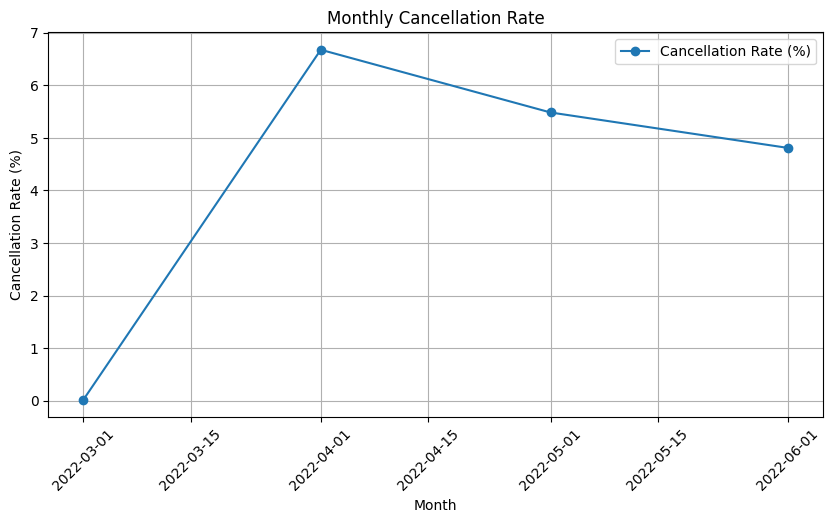

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue["Year_Month"],
    monthly_revenue["Cancellation_Rate"] * 100,
    marker='o',
    label="Cancellation Rate (%)"
)

plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

## best selling products

## top products by revenue

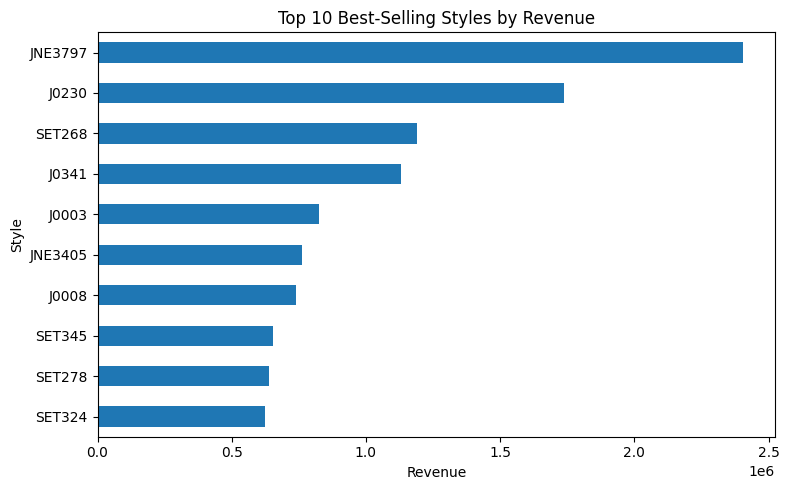

In [ ]:
top_products = (
    df[df["Order_Success"] == 1].groupby("Style")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling Styles by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()


In [ ]:
top_qty = (
    df[df["Order_Success"] == 1].groupby("Style")["Qty"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_qty

,Qty
Style,
JNE3797,3278
JNE3405,1911
SET268,1598
J0230,1558
J0341,1370
J0003,1257
SET324,1049
SET345,1041
JNE3373,975


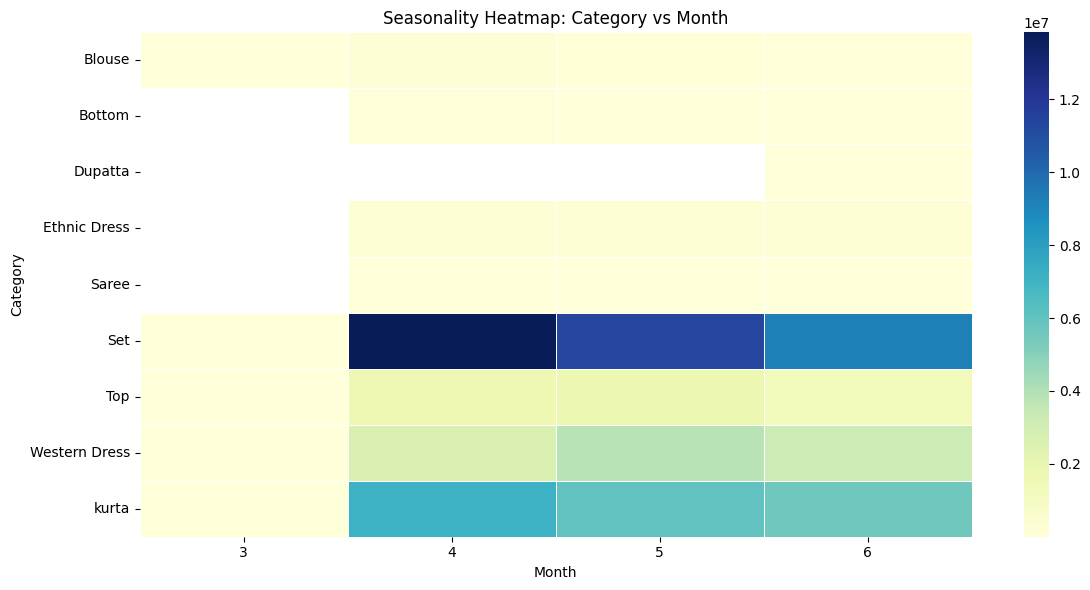

In [ ]:
seasonality = (
    df[df["Order_Success"] == 1].groupby(["Category", "month"])["Amount"]
    .sum()
    .unstack()
)

plt.figure(figsize=(12,6))
sns.heatmap(seasonality, cmap="YlGnBu", linewidths=0.5)
plt.title("Seasonality Heatmap: Category vs Month")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [ ]:
aov=df[df['Is_Cancelled'] != 1]["Amount"].sum() / df['Order ID'].nunique()

In [ ]:
aov

np.float64(585.0321691371976)

In [ ]:
aov_category = (
    df.groupby("Category")
    .agg(
        Revenue=("Amount", "sum"),
        Orders=("Order ID", "nunique")
    )
)

aov_category["AOV"] = aov_category["Revenue"] / aov_category["Orders"]
aov_category.sort_values("AOV", ascending=False)


,Revenue,Orders,AOV
Category,,,
Saree,129301.38,144,897.93
Set,41902106.95,47836,875.95
Western Dress,11803998.71,14989,787.51
Ethnic Dress,838226.31,1147,730.80
Top,5584873.50,10154,550.02
Blouse,481987.72,897,537.33
kurta,22692230.38,46551,487.47
Dupatta,915.00,2,457.50
Bottom,159091.64,410,388.03


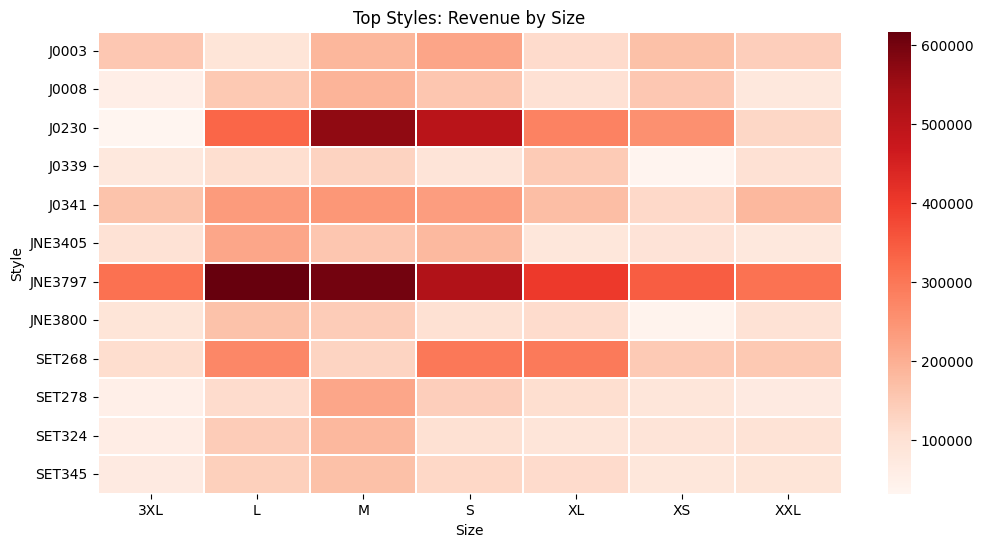

In [ ]:
top_styles = (
    df.groupby("Style")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

filtered = df[df["Style"].isin(top_styles)]

pivot = (
    filtered.groupby(["Style", "Size"])["Amount"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Reds", linewidths=0.3)
plt.title("Top Styles: Revenue by Size")
plt.show()


## Customer Insights

## Cancelled %age

In [ ]:
cancel_rate = df["Is_Cancelled"].mean() * 100
cancel_rate


np.float64(15.857517333374696)

In [ ]:
cancel_rate1 = (df["Is_Cancelled"].sum() / len(df)) * 100
cancel_rate1

np.float64(15.857517333374696)

16% of all orders do not convert to realized revenue.

## Cancelled by category

In [ ]:
cancel_by_category = (
    df.groupby("Category")["Is_Cancelled"]
    .mean()
    .sort_values(ascending=False) * 100
)

cancel_by_category


,Is_Cancelled
Category,
Set,16.28
kurta,16.06
Western Dress,15.93
Bottom,15.00
Ethnic Dress,13.99
Blouse,13.82
Saree,13.41
Top,13.28
Dupatta,0.00


In [ ]:
cancel_by_size = (
    df.groupby("Size")["Is_Cancelled"]
    .mean()
    .sort_values(ascending=False) * 100
)

cancel_by_size


,Is_Cancelled
Size,
XS,18.24
S,16.87
M,16.67
L,15.82
XL,15.30
XXL,14.92
3XL,14.21
Free,13.98
4XL,12.21


In [ ]:
cancel_by_fulfilment = (
    df.groupby("Fulfilment")["Is_Cancelled"]
    .mean() * 100
)

cancel_by_fulfilment


,Is_Cancelled
Fulfilment,
Amazon,12.80
Merchant,22.84


In [ ]:
df.groupby("Is_Cancelled")["Amount"].mean()


,Amount
Is_Cancelled,
0,648.97
1,644.74


In [ ]:
## Differentiating B2B vs. B2C customer behavior for targeted marketing.

df.groupby("B2B").agg(
    Avg_Order_Value=("Amount", "mean"),
    Avg_Qty=("Qty", "mean"),
    Cancel_Rate=("Is_Cancelled", "mean")
)

,Avg_Order_Value,Avg_Qty,Cancel_Rate
B2B,,,
False,647.92,0.90,0.16
True,703.21,0.97,0.09


## Logistic & Fulfilment Optimization

In [ ]:
fulfilment_perf = df.groupby("Fulfilment").agg(
    Order_Success_Rate=("Order_Success", "mean"),
    In_Process_Rate=("In_Process", "mean"),
    Cancellation_Rate=("Is_Cancelled", "mean"),
    Avg_Order_Value=("Amount", "mean"),
    Orders=("Order ID", "count")
)

fulfilment_perf[["Order_Success_Rate", "Cancellation_Rate","In_Process_Rate"]] *= 100
fulfilment_perf

,Order_Success_Rate,In_Process_Rate,Cancellation_Rate,Avg_Order_Value,Orders
Fulfilment,,,,,
Amazon,86.73,0.47,12.80,649.18,89672
Merchant,73.24,3.92,22.84,646.29,39270


Due to the absence of shipment or delivery timestamps, direct measurement of shipping duration was not possible.
Logistics performance was therefore assessed using outcome-based proxies such as order success rate, cancellation rate,
and fulfilment reliability across fulfilment models, geographies, and courier statuses.
Insights:
1.Amazon fulfilment is more reliable than Merchant.
2.Merchant fulfilment shows higher cancellation risk.
Fulfilment choice impacts realized revenue.

## PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION

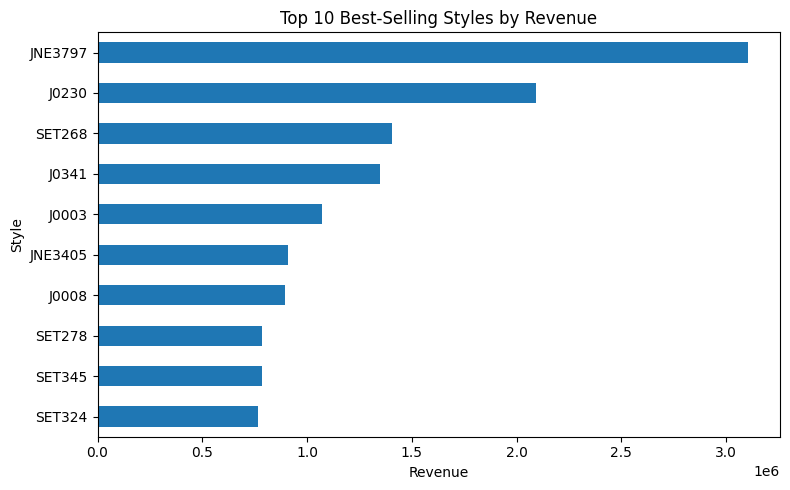

In [ ]:
## Identifying high-demand product categories.

top_products = (
    df.groupby("Style")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling Styles by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

Since we don’t have warehouse stock or lead-time data,
this is a demand-side inventory optimization, which is perfectly valid.

In [ ]:
df["Qty"].describe()

,Qty
count,128942.00
mean,0.90
std,0.31
min,0.00
25%,1.00
50%,1.00
75%,1.00
max,15.00


Mean → typical order size
75th / 90th percentile → bulk or high-demand orders

Business meaning : How many units customers usually buy per order.

In [ ]:
## Avg qty per style

avg_qty_style = (
    df.groupby(["Style","Category"])["Qty"]
    .mean()
    .sort_values(ascending=False)
)

avg_qty_style.head(10)

,,Qty
Style,Category,
BL017,Blouse,5.67
BL020,Blouse,2.00
SAR135,Saree,1.67
BL086,Blouse,1.33
BL022,Blouse,1.25
SET442,Set,1.25
SET315,Set,1.25
AN211,Bottom,1.17
SAR137,Saree,1.17


In [ ]:
avg_qty_style = (
    df.groupby(["Style","Category"])["Qty"]
    .mean()
    .sort_values(ascending=False)
)

avg_qty_style.head(10)

,,Qty
Style,Category,
BL017,Blouse,5.67
BL020,Blouse,2.00
SAR135,Saree,1.67
BL086,Blouse,1.33
BL022,Blouse,1.25
SET442,Set,1.25
SET315,Set,1.25
AN211,Bottom,1.17
SAR137,Saree,1.17


Categories & Styles with higher average quantity like Blouse of these two styles(BL017,BL020) need faster replenishment cycles.

In [ ]:
avg_qty_size = (
    df.groupby("Size")["Qty"]
    .median()
    .sort_values(ascending=False)
)

avg_qty_size


,Qty
Size,
3XL,1.00
4XL,1.00
5XL,1.00
6XL,1.00
Free,1.00
L,1.00
M,1.00
S,1.00
XL,1.00


avg order for all sizes are same which is 1.

In [ ]:
## High demand styles(stockout risk)

style_demand = df.groupby("Style").agg(
    Avg_Qty=("Qty", "mean"),
    Total_Qty=("Qty", "sum"),
    Orders=("Order ID", "count")
)

style_demand.sort_values("Total_Qty", ascending=False).head(10)


,Avg_Qty,Total_Qty,Orders
Style,,,
JNE3797,0.87,3693,4224
JNE3405,0.91,2066,2262
SET268,0.93,1732,1860
J0230,0.92,1710,1867
J0341,0.90,1472,1630
J0003,0.85,1390,1627
SET324,0.90,1153,1284
SET345,0.91,1134,1250
JNE3373,0.91,1070,1173


JNE3797,JNE3405,SET268 are more consumed styles of all.

## Slow movers

In [ ]:
slow_movers = style_demand[
    (style_demand["Orders"] < style_demand["Orders"].quantile(0.25)) &
    (style_demand["Total_Qty"] < style_demand["Total_Qty"].quantile(0.25))
]

slow_movers.head()


,Avg_Qty,Total_Qty,Orders
Style,,,
AN201,1.00,5,5
AN202,1.00,7,7
AN203,1.00,1,1
AN205,1.00,7,7
AN206,1.00,3,3


Low order frequency, Low total movement -- Overstock risk

**Overstock risky sizes.**

In [ ]:
size_velocity = df.groupby("Size")["Qty"].sum().sort_values()

size_velocity


,Qty
Size,
Free,368
4XL,397
5XL,513
6XL,688
XS,9939
3XL,13525
S,15337
XXL,16511
XL,18928


## Size–Style Inventory Planning (Practical)

In [ ]:
size_style_qty = (
    df.groupby(["Style", "Size"])["Qty"]
    .sum()
    #.unstack(fill_value=0)
)

size_style_qty.sort_values(ascending=False).head(10)


Style    Size
JNE3797  L       730
         M       699
         S       610
JNE3405  L       484
JNE3797  XL      473
J0230    M       470
         S       419
JNE3797  XS      411
JNE3405  S       399
JNE3797  XXL     387
Name: Qty, dtype: int64

In [ ]:
  Area	                   Recommendation
High Avg Qty Styles  	   Maintain higher safety stock
Core Sizes(M, L, etc.)	 Allocate disproportionate inventory
Slow-Moving Styles	     Reduce stock, use promotions
Category Planning	       Shorter replenishment cycles for high-qty categories


## Cancellation Rate by Category

## Status by category

In [ ]:

cancel_by_category = (
    df.groupby("Category")["Is_Cancelled"]
    .mean()
    .sort_values(ascending=False) * 100
)

cancel_by_category


,Is_Cancelled
Category,
Set,16.28
kurta,16.06
Western Dress,15.93
Bottom,15.00
Ethnic Dress,13.99
Blouse,13.82
Saree,13.41
Top,13.28
Dupatta,0.00


Insight:
High cancellation categories → quality, fit, or expectation mismatch.
These categories require priority intervention.

## Order Success by category

In [ ]:
Success_order_by_category = (
    df.groupby("Category")["Order_Success"]
    .mean()
    .sort_values(ascending=False) * 100
)

Success_order_by_category


,Order_Success
Category,
Dupatta,100.00
Saree,85.98
Blouse,85.53
Top,85.32
Ethnic Dress,85.23
kurta,82.68
Set,82.15
Bottom,82.05
Western Dress,81.72


## In-Process by category

In [ ]:
In_process_by_category = (
    df.groupby("Category")["In_Process"]
    .mean()
    .sort_values(ascending=False) * 100
)

In_process_by_category

,In_Process
Category,
Bottom,2.95
Western Dress,2.36
Set,1.58
Top,1.40
kurta,1.25
Ethnic Dress,0.78
Blouse,0.65
Saree,0.61
Dupatta,0.00


## Identify Problematic Products (Style-level)

In [ ]:
style_stats = df.groupby("Style").agg(
    Orders=("Order ID", "count"),
    Cancel_Rate=("Is_Cancelled", "mean")
)

problem_styles = style_stats[
    (style_stats["Orders"] >= 20) &   # avoid noise
    (style_stats["Cancel_Rate"] > style_stats["Cancel_Rate"].quantile(0.75))
].sort_values("Cancel_Rate", ascending=False)

problem_styles.head(10)


,Orders,Cancel_Rate
Style,,
SET195,24,0.46
JNE3475,25,0.40
JNE3608,77,0.38
J0350,43,0.37
J0292,32,0.34
JNE3255,30,0.33
JNE3488,21,0.33
JNE3408,46,0.33
BTM038,22,0.32


These are top 10 products where cancellation rate is observed to be very high,
which might indicate that the style is not liked by people.
So, you can consider either putting high discount on remaining stocks to empty it or can think of improving these styles.

## Cancel by size

In [ ]:
cancel_by_size = (
    df.groupby("Size")["Is_Cancelled"]
    .mean()
    .sort_values(ascending=False) * 100
)

cancel_by_size

,Is_Cancelled
Size,
XS,18.24
S,16.87
M,16.67
L,15.82
XL,15.30
XXL,14.92
3XL,14.21
Free,13.98
4XL,12.21


Insights:
1. High-cancel sizes → fit or sizing chart issues.
2. Action: revise size guide, images, descriptions.

In [ ]:
      Issue	                     Recommendation
High-return categories	   Improve product quality checks
Size-driven returns	       Update size charts & visuals
Problematic styles	       Pause promotions, review supplier
Merchant fulfilment	       Enforce stricter SLAs
Low-confidence orders	   Improve descriptions & reviews

## Cancel by fulfilment

In [ ]:


cancel_by_fulfilment = (
    df.groupby("Fulfilment")["Is_Cancelled"]
    .mean() * 100
)

cancel_by_fulfilment


,Is_Cancelled
Fulfilment,
Amazon,12.80
Merchant,22.84


Enforce stricter SLAs for fulfilments by merchants.


In-short, In the absence of explicit customer feedback, I used returns and cancellations as dissatisfaction proxies,
identified high-risk products and categories using volume-adjusted metrics, and translated insights into concrete quality and service improvements.

In [ ]:
df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22', 'date_clean', 'year', 'month',
       'quarter', 'Is_Cancelled', 'Order_Success', 'In_Process'],
      dtype='object')

**Script for connecting to sql, which will be used in building power bi dashboard**

In [ ]:
from sqlalchemy import create_engine

server = "DELL\SQLEXPRESS07"      # e.g. DESKTOP-ABC\\SQLEXPRESS
database = "EcommSalesAnalysis"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server"
)

In [ ]:
df_sales = df.rename(columns={"Order ID": "Order_ID","date_clean":"Date_Clean","year":"Year_1","month":"Month_1",
                              "quarter":"Quarter_1","promotion-ids":"promotion_ids","Sales_Channel ":"Sales_Channel","Status": "Status_1"})



In [ ]:
SalesData_sql = df_sales[
    [
        "Order_ID",
        "Date_Clean",
        "Status_1",
        "Fulfilment",
        "Sales_Channel",
        "ship_service_level",
        "Style",
        "SKU",
        "Category",
        "Size",
        "Qty",
        "Amount",
        "promotion_ids",
        "B2B",
        "fulfilled_by",
        'Year_1',
        'Month_1',
        'Quarter_1',
        'Is_Cancelled',
        'Order_Success',
        'In_Process'


    ]
]

SalesData_sql.to_sql(
    "EcommSalesAnalysis",
    engine,
    if_exists="append",
    index=False,
    chunksize=10000
)



44

**Insights -**

Problem Statement:
The e-commerce company is facing multiple
operational challenges that hinder growth and
customer satisfaction &
to address these issues, the company is
leveraging data
driven insights to optimize
operations.
Dataset provided is sales data.csv with columns like
Order ID, Date, Status, Fulfilment, Sales Channel, ship
service level, Style,
SKU, Category, Size, Quantity, currency, Amount, ship
city, ship state, ship
country, ship postal code, promotion_ids , B 2 B, fulfilled_by


Dataset Overview
• Total Orders: 1,28,942
• Cancelled Orders: 20,447
• Overall Cancellation %: 16.9


* As per the histogram, we can see 250-1000 is the range which most of the people Ordering,
* Also as per the box plot there are also outliers where people have Ordered worth more than 3k.

* Most of the people have accepted the delivery than cancelling it.
* Majorly fullfilled by amazon,followed by expedited facilty.Set & kurta seems to be the most ordered items.
* Size M is the most ordered
* size indicating there are more of M size people.Highest no. of orders coming from maharashtra, karnataka, tamil nadu.

Due to the absence of shipment or delivery timestamps, direct measurement of shipping duration was not possible.
Logistics performance was therefore assessed using outcome-based proxies such as order success rate,
cancellation rate, and fulfilment reliability across fulfilment models, geographies, and courier statuses.

 Insights:
 1.Amazon fulfilment is more reliable than Merchant.
 2.Merchant fulfilment shows higher cancellation risk. Fulfilment choice impacts realized revenue.


* Categories & Styles with higher average quantity like Blouse of these two styles(BL017,BL020) need faster replenishment cycles.

* avg order for all sizes are same which is 1.

* JNE3797,JNE3405,SET268 are more consumed styles of all.

* Low order frequency, Low total movement -- Overstock risk(AN201,AN202,AN203,AN205,AN206)

Top 3 cancelled styles  are -

Set	16.28%
kurta	16.06%
Western Dress	15.93%
Insight: High cancellation categories → quality, fit, or expectation mismatch. These categories require priority intervention.

These are top 3 products where cancellation rate is observed to be very high, which might indicate that the style is not liked by people.
So, you can consider either putting high discount on remaining stocks to empty it or can think of improving these styles.
SET195 46%, JNE3475	40%, JNE3608	38%


In the absence of explicit customer feedback, I used returns and cancellations as dissatisfaction proxies,
identified high-risk products and categories using volume-adjusted metrics,
and translated insights into concrete quality and service improvements.

top 3 cancelled sizes are XS 18.24%,S 16.87%,M 16.67% .

•For this analysis, realized revenue is defined as orders with status Shipped Delivered to Buyer and Shipped ””;
it peaks at ₹ 26 M in April and declines in the subsequent months
•The value of canceled orders decreased from ₹ 5 M in April to ₹ 4 M in May and ₹ 3.8 M in June
•Orders in process , defined as statuses Shipped Lost in Transit, Transit,” Shipped Out for Delivery, Delivery,” Shipped Picked
Up,Up,” Pending,Pending,” Pending Waiting for Pick Up, Up,” Shipped Damaged,Damaged,” and Shipping, amount to 18 K in April
and May , rising sharply to 1.3 M in June

* Average cancellation rate is 16.9%

* Revenue is highest on Sundays relative to the
rest of the week.

* JNE3797 , J 0230 , SET 268 are top 3 styles generating revenue of 2.4 m, 1.8 m, 1.2 m. Most ordered category is SET in Apr, May, Jun followed by kurta.

* Fulfilled by Amazon orders have a 12 % cancellation rate , compared to 22 % for Merchant fulfilled orders.



**Conclusion & Recommendations**

Strengthen weekend promotions.
Improve fulfilment to reduce cancellations.
Align inventory with demand patterns.
Use insights for data-driven decisions.
Improve product quality checks, fit, or expectation mismatch for High-return categories as these categories require priority intervention.
Update size charts & visuals.
Pause promotions, review supplier for Problematic styles.
Enforce stricter SLAs for Merchant fulfilment.
Improve descriptions & reviews for Low-confidence orders.
